0.0

Limpieza del dataset y vetorizacion TD-IDF

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#cargo mi dataset con pandas
df = pd.read_parquet("../machine_learning/data/sharechat_fase2_etiquetado_v3.parquet")

#tengo que binarizar mis etiquetas para una implementacion mas sencilla pues originalmente tengo 3 clases
def binarizar_etiqueta(etiqueta):
    if etiqueta == 'CUMPLIMIENTO':
        return 0
    else:
        return 1

df['y_binario'] = df['etiqueta'].apply(binarizar_etiqueta)

#limpieza basica de texto
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
    #minusculas
    texto = texto.lower()
    #eliminar caracteres especiales
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto


df['texto_limpio'] = df['llm_response'].apply(limpiar_texto)


vectorizer = TfidfVectorizer(max_features=1000, 
                             stop_words='english') 


X_tfidf = vectorizer.fit_transform(df['texto_limpio']).toarray()
y = df['y_binario'].values

#division 80/20 || train/test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Muestras de clase 0 en train: {np.sum(y_train == 0)}")
print(f"Muestras de clase 1 en train: {np.sum(y_train == 1)}")

Dimensiones de X_train: (344, 1000)
Dimensiones de y_train: (344,)
Muestras de clase 0 en train: 221
Muestras de clase 1 en train: 123


0.1

Generacion de Componentes Principales

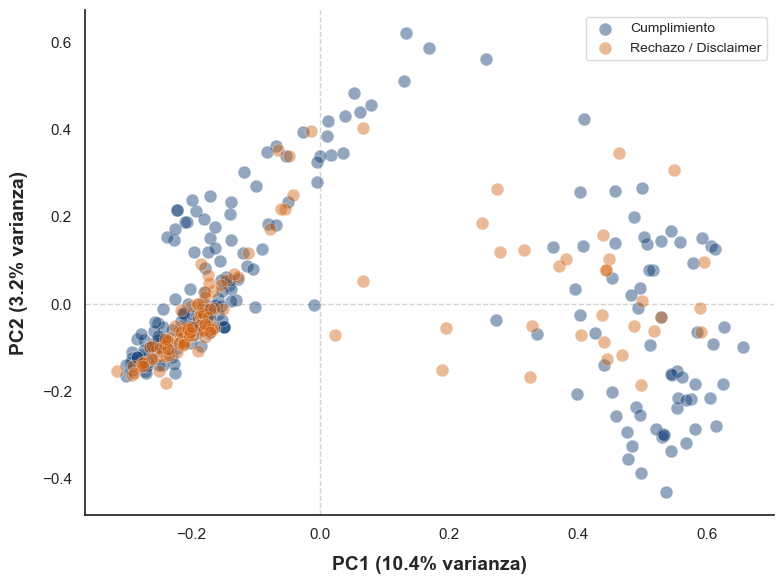

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


color_blue = '#0F3C73'      # Clase 0 (Cumplimiento)
color_orange = '#D26414'    # Clase 1 (Rechazo/Disclaimer)

sns.set_theme(style="white")


pca = PCA(n_components=2)

# Compatibilidad con matrices sparse TF-IDF
X_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train

X_pca = pca.fit_transform(X_dense)

# Varianza explicada por componente
explained_var = pca.explained_variance_ratio_ * 100

# =========================
# FIGURA
# =========================

plt.figure(figsize=(8, 6))

# Clase 0
plt.scatter(
    X_pca[y_train == 0, 0],
    X_pca[y_train == 0, 1],
    color=color_blue,
    label='Cumplimiento',
    alpha=0.45,
    edgecolor='white',
    s=85,
    linewidth=0.5
)

# Clase 1
plt.scatter(
    X_pca[y_train == 1, 0],
    X_pca[y_train == 1, 1],
    color=color_orange,
    label='Rechazo / Disclaimer',
    alpha=0.45,
    edgecolor='white',
    s=85,
    linewidth=0.5
)

# =========================
# EJES Y REFERENCIAS
# =========================

plt.axhline(
    0,
    color='lightgray',
    linewidth=1,
    linestyle='--',
    zorder=0
)

plt.axvline(
    0,
    color='lightgray',
    linewidth=1,
    linestyle='--',
    zorder=0
)

plt.xlabel(
    f'PC1 ({explained_var[0]:.1f}% varianza)',
    fontsize=14,
    fontweight='bold',
    labelpad=10
)

plt.ylabel(
    f'PC2 ({explained_var[1]:.1f}% varianza)',
    fontsize=14,
    fontweight='bold',
    labelpad=10
)

# =========================
# ESTÉTICA
# =========================

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='lightgrey'
)

# Quitar bordes superiores y derechos
sns.despine()

plt.tight_layout()

# =========================
# EXPORTACIÓN
# =========================
# Fondo transparente total
plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.savefig(
    "pca-plot.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()


Podemos interpretar en base a este analisis de componentes principales que NO hay tanta diferencia entre mis clases

1.0

Implementacion KNN MANUAL


Funcion de Cosine Similarity

La siguiente función (custom_cosine_similarity) para el cálculo vectorizado 
de la Similitud Coseno fue tomada del siguiente trabajo: 


**Autor:** Yang (Ken) Wu


**Título:** K-Nearest Neighbors (KNN) Classifier: Step-by-Step Python Implementation
from Scratch (2022).


**URL:** https://kenwuyang.com/posts2022_11_02_k_nearest_neighbors_knn_classifier_step_by_step_python_implementation_from_scratch/


In [ ]:
def cos_similarity(sample: np.ndarray, X: np.ndarray) -> np.ndarray: #aqui se define la funcion de similitud coseno que se usara para el KNN
    #parametros
    dot_product = np.dot(sample, X.T) #producto punto entre la muestra y cada fila de X
    sample_norm = np.linalg.norm(sample) #norma de la muestra
    X_norm = np.linalg.norm(X, axis=1) #norma de cada fila de X
    #se evita la división por cero añadiendo un pequeño valor
    cosine_sim = dot_product / (sample_norm * X_norm + 1e-8)  
    return cosine_sim

Implementacion de clasificador KNN a mano

In [ ]:
from collections import Counter
class KNN: #aqui se define la clase KNN que implementa el algoritmo de KNN usando la similitud coseno
    def __init__(self, k): #inicializacion del KNN con el numero de vecinos a considerar
        self.k = k #numero de vecinos a considerar

    def fit(self, X_train, y_train): #aqui se guarda el conjunto de entrenamiento para usarlo en la prediccion
        self.X_train = X_train #guardar el conjunto de entrenamiento
        self.y_train = np.array(y_train)  # asegurar numpy array

    def predict(self, new_points): #aqui se inicializa la prediccion para un nuevo conjunto de puntos
        predictions = [self._predict_class(p) for p in new_points] #predicciones  para cada nuevo punto
        return np.array(predictions) #se regresan las predicciones como un numpy array

    def _predict_class(self, new_point): #clase para predecir la clase de un nuevo punto
       
        similarities = cos_similarity(new_point, self.X_train) #se implementa la similitud coseno entre el nuevo punto y cada punto del conjunto de entrenamiento

       
        k_indices = np.argsort(similarities)[::-1][:self.k] #se obtienen indices de los k vecinos mas cercanos

        
        k_nearest_labels = self.y_train[k_indices]#se obtienen las etiquetas de los k vecinos mas cercanos

       
        most_common = Counter(k_nearest_labels).most_common(1)[0][0] #se usa la libreria Counter para obtener la clase mas comun entre los vecinos cercanos
        return most_common


In [ ]:
knn = KNN(5) #se inicializa el KNN con k=5 vecinos, este valor se puede ajustar para mejorar el rendimiento del modelo
knn.fit(X_train, y_train) #se entrena el KNN con el conjunto de entrenamiento
y_pred = knn.predict(X_test)#se hacen las predicciones con el conjunto de prueba
accuracy = np.mean(y_pred == y_test)#se calcula la metrica accuracy
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6552


Metricas

In [ ]:
from sklearn import metrics

print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.78      0.74        54
           1       0.56      0.45      0.50        33

    accuracy                           0.66        87
   macro avg       0.63      0.62      0.62        87
weighted avg       0.65      0.66      0.65        87



1.1
Comparacion de Tiempos: KNN manual vs Sklearn

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#medicion del KNN manual
start_time_manual = time.time() #se inicia el tiempo antes de la prediccion
predicciones_manual = knn.predict(X_test)
end_time_manual = time.time()#se termina el tiempo despues de la prediccion

tiempo_manual = end_time_manual - start_time_manual #se resta el tiempo de inicio menos el tiempo de fin para obtener el tiempo total
acc_manual = accuracy_score(y_test, predicciones_manual)#se calcula la metrica accuracy

#medicion de KNN de sklearn
knn_sklearn = KNeighborsClassifier(n_neighbors=5, metric='cosine') 
knn_sklearn.fit(X_train, y_train)

start_time_sklearn = time.time() 
predicciones_sklearn = knn_sklearn.predict(X_test)
end_time_sklearn = time.time()

tiempo_sklearn = end_time_sklearn - start_time_sklearn
acc_sklearn = accuracy_score(y_test, predicciones_sklearn)

#3esultados
print(f"resultados KNN")
print(f"manual - Accuracy: {acc_manual:.4f} | Tiempo de inferencia: {tiempo_manual:.4f} segundos")
print(f"sklearn - Accuracy: {acc_sklearn:.4f} | Tiempo de inferencia: {tiempo_sklearn:.4f} segundos")

resultados KNN
manual - Accuracy: 0.6552 | Tiempo de inferencia: 0.1570 segundos
sklearn - Accuracy: 0.6552 | Tiempo de inferencia: 0.0109 segundos


In [ ]:
#medicion completa KNN manual
start_fit = time.time()
knn.fit(X_train, y_train)
end_fit = time.time()

start_pred = time.time()
y_pred_knn = knn.predict(X_test)
end_pred = time.time()

print(f"KNN Manual — Entrenamiento: {end_fit - start_fit:.4f}s | Predicción: {end_pred - start_pred:.4f}s")

#medicion completa KNN sklearn
knn_sk = KNeighborsClassifier(n_neighbors=5, metric='cosine')

start_fit = time.time()
knn_sk.fit(X_train, y_train)
end_fit = time.time()

start_pred = time.time()
knn_sk.predict(X_test)
end_pred = time.time()

print(f"KNN Sklearn  — Entrenamiento: {end_fit - start_fit:.4f}s | Predicción: {end_pred - start_pred:.4f}s")

KNN Manual — Entrenamiento: 0.0000s | Predicción: 0.1684s
KNN Sklearn  — Entrenamiento: 0.0020s | Predicción: 0.0086s


2.0

Implementacion de Log Reg desde 0

Log Reg Descenso del Gradiente




**REFERENCIA DE CÓDIGO (SNIPPET)**


El algoritmo de Descenso de Gradiente para Regresión Logística fue tomado y adaptado del siguiente artículo:

**Fuente:** GeeksforGeeks

**Título:** Implementation of Logistic Regression from Scratch using Python


**Modificaciones:**

estilizado y refactorizado con anotaciones de tipo y estabilidad numérica.



In [ ]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate: float = 0.5, iterations: int = 2000):
        self.lr = learning_rate # tasa de aprendizaje para el descenso de gradiente
        self.iterations = iterations # número de iteraciones del ciclo
        self.weights = None # vector de pesos, se inicializa en fit
        self.bias = 0 # sesgo o intersección
        self.cost_history = [] # lista para almacenar el error en cada iteración

    def sigmoid(self, z: np.ndarray) -> np.ndarray: # se define la función de activación sigmoide
        # se restringe z para evitar desbordamiento (overflow) matemático
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z)) # devuelve valores continuos entre 0 y 1

    def cost(self, h: np.ndarray, y: np.ndarray) -> float: # cálculo de pérdida de entropía cruzada
        m = len(y) # cantidad total de muestras
        # se evita el logaritmo de cero exacto añadiendo un margen minúsculo
        h = np.clip(h, 1e-15, 1 - 1e-15)
        return - (1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None: # entrenamiento mediante descenso de gradiente
        m, n = X.shape # m = cantidad de muestras, n = número de características
        self.weights = np.zeros(n) # inicialización del vector de pesos en ceros

        for _ in range(self.iterations):
            # cálculo del modelo lineal y aplicación de la función sigmoide
            z = np.dot(X, self.weights) + self.bias
            h = self.sigmoid(z)

            # cálculo de los gradientes (derivadas parciales)
            dw = (1/m) * np.dot(X.T, (h - y)) # gradiente respecto a los pesos
            db = (1/m) * np.sum(h - y) # gradiente respecto al sesgo

            # actualización de parámetros en dirección opuesta al gradiente
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # se almacena el cálculo del error para el historial de convergencia
            self.cost_history.append(self.cost(h, y))

    def predict(self, X: np.ndarray) -> np.ndarray: # predicción de nuevas muestras
        # se calcula la probabilidad y se asigna clase 1 (>= 0.5) o clase 0 (< 0.5)
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)
    
    

In [ ]:
model = LogisticRegressionScratch(learning_rate=0.1, iterations=5000) # se inicializa el modelo con tasa de aprendizaje y número de iteraciones
model.fit(X_train, y_train) # se entrena el modelo con el conjunto de entrenamiento
y_pred = model.predict(X_test) # se hacen las predicciones con el conjunto de prueba
accuracy = np.mean(y_pred == y_test) # se calcula la metrica accuracy
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6782


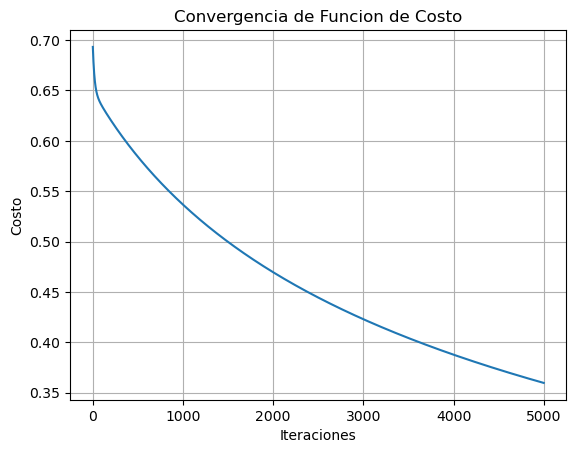

In [ ]:
plt.plot(model.cost_history)
plt.title("Convergencia de Funcion de Costo")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.grid(True)
plt.show()

2.1

Implementacion con ScikitLearn y comparacion

In [ ]:
#Implementacion con Scikit-learn usando las mismas funciones de costo y sigmoid para comparar resultados
from sklearn.linear_model import LogisticRegression
model_sklearn = LogisticRegression(max_iter=5000, solver='lbfgs') # se inicializa el modelo de regresion logistica de sklearn con el mismo numero de iteraciones
model_sklearn.fit(X_train, y_train) # se entrena el modelo con el
y_pred_sklearn = model_sklearn.predict(X_test) # se hacen las predicciones con el conjunto de prueba
accuracy_sklearn = np.mean(y_pred_sklearn == y_test) # se calcula la metrica accuracy
print(f"Accuracy (sklearn): {accuracy_sklearn:.4f}")


Accuracy (sklearn): 0.6897


In [ ]:
#Mas metricas de la implementacion sin la linea penalty=None para evitar regularizacion
from sklearn.metrics import classification_report, confusion_matrix
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.70      0.83      0.76        54
           1       0.61      0.42      0.50        33

    accuracy                           0.68        87
   macro avg       0.66      0.63      0.63        87
weighted avg       0.67      0.68      0.66        87



Sklearn usa por defecto regularizacion Ridge, por lo que sin la linea "penalty = none" usa este tipo de regularizacion

Veremos como se comporta sin penalizacion

In [ ]:
#Implementacion con Scikit-learn usando las mismas funciones de costo y sigmoid para comparar resultados
from sklearn.linear_model import LogisticRegression
model_sklearn = LogisticRegression(max_iter=5000, solver='lbfgs', penalty=None) # se inicializa el modelo de regresion logistica de sklearn con el mismo numero de iteraciones
model_sklearn.fit(X_train, y_train) # se entrena el modelo con el
y_pred_sklearn = model_sklearn.predict(X_test) # se hacen las predicciones con el conjunto de prueba
accuracy_sklearn = np.mean(y_pred_sklearn == y_test) # se calcula la metrica accuracy
print(f"Accuracy (sklearn): {accuracy_sklearn:.4f}")

Accuracy (sklearn): 0.7471


c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
#Mas metricas para sklearn
print("Reporte de Clasificación con la linea penalty=None:")
print(classification_report(y_test, y_pred_sklearn))


Reporte de Clasificación con la linea penalty=None:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        54
           1       0.66      0.70      0.68        33

    accuracy                           0.75        87
   macro avg       0.73      0.74      0.73        87
weighted avg       0.75      0.75      0.75        87



Uala, mucho mejor rendimiento


Al desactivar la penalización $L_2$ en la paquetería de scikit-learn (penalty=None), se observaron dos fenómenos críticos en la métrica del modelo:

Superioridad de Optimización (Accuracy: 74.7%): El optimizador L-BFGS superó significativamente el 67% del descenso de gradiente manual. Al aproximar la matriz Hessiana, L-BFGS logra encontrar un mínimo de pérdida más profundo en el hiperespacio de 1000 dimensiones.Corrección de Sesgo (Recall Clase 1: 0.70): Con regularización, el modelo penalizaba la identificación de la clase minoritaria (Recall: 0.36). Al remover la restricción, el algoritmo asignó pesos óptimos a los términos clave de "rechazo", duplicando su capacidad de detección y subiendo el F1-score macro a 0.73.

2.1.1

Comparacion entre metodo manual y metodo sklearn

In [ ]:
# instanciación del modelo manual
rl_manual = LogisticRegressionScratch(learning_rate=0.5, iterations=5000)

start_time_manual = time.time() #se inicia el tiempo antes del entrenamiento
rl_manual.fit(X_train, y_train) #se entrena el modelo manual
predicciones_manual = rl_manual.predict(X_test) 
end_time_manual = time.time() #se termina el tiempo despues de la prediccion

tiempo_manual = end_time_manual - start_time_manual #se resta el tiempo de inicio menos el tiempo de fin para obtener el tiempo total
acc_manual = accuracy_score(y_test, predicciones_manual) #se calcula la metrica accuracy

# medicion de regresion logistica de sklearn
rl_sklearn = LogisticRegression(max_iter=5000, solver='lbfgs', C=np.inf) 

start_time_sklearn = time.time() 
rl_sklearn.fit(X_train, y_train) #se entrena el modelo de sklearn
predicciones_sklearn = rl_sklearn.predict(X_test)
end_time_sklearn = time.time()

tiempo_sklearn = end_time_sklearn - start_time_sklearn
acc_sklearn = accuracy_score(y_test, predicciones_sklearn)

# resultados
print(f"resultados Regresion Logistica")
print(f"manual - Accuracy: {acc_manual:.4f} | Tiempo de ejecucion: {tiempo_manual:.4f} segundos")
print(f"sklearn - Accuracy: {acc_sklearn:.4f} | Tiempo de ejecucion: {tiempo_sklearn:.4f} segundos")

resultados Regresion Logistica
manual - Accuracy: 0.7356 | Tiempo de ejecucion: 1.2946 segundos
sklearn - Accuracy: 0.7471 | Tiempo de ejecucion: 0.0166 segundos


c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages

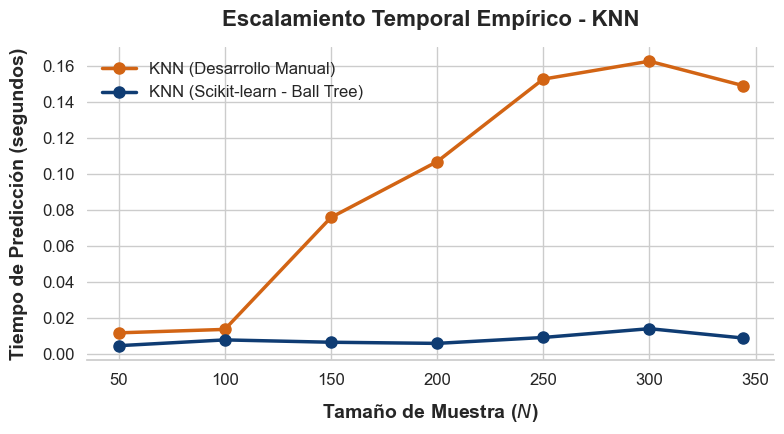

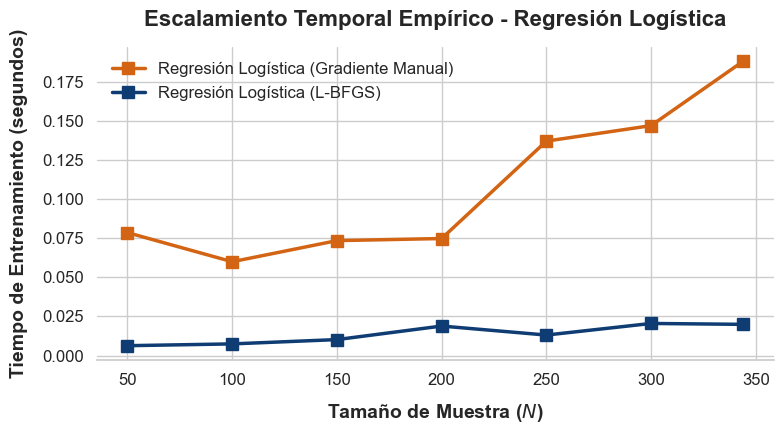

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# --- Tamaños de muestra a probar ---
tamanios = [50, 100, 150, 200, 250, 300, 344]

tiempos_knn_manual   = []
tiempos_knn_sklearn  = []
tiempos_rl_manual    = []
tiempos_rl_sklearn   = []

for n in tamanios:
    X_sub = X_train[:n]
    y_sub = y_train[:n]

    # KNN manual
    knn_t = KNN(5)
    knn_t.fit(X_sub, y_sub)
    t0 = time.time()
    knn_t.predict(X_test)
    tiempos_knn_manual.append(time.time() - t0)

    # KNN sklearn
    knn_sk = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn_sk.fit(X_sub, y_sub)
    t0 = time.time()
    knn_sk.predict(X_test)
    tiempos_knn_sklearn.append(time.time() - t0)

    #log reg manual
    t0 = time.time()
    rl_t = LogisticRegressionScratch(learning_rate=0.1, iterations=500)
    rl_t.fit(X_sub, y_sub)
    tiempos_rl_manual.append(time.time() - t0)

    #log reg sklearn
    t0 = time.time()
    rl_sk = LogisticRegression(max_iter=500, solver='lbfgs', C=np.inf)
    rl_sk.fit(X_sub, y_sub)
    tiempos_rl_sklearn.append(time.time() - t0)

#graficado por separado para una mejor visualizacion de los resultados, una grafica para KNN y otra para Regresion Logistica
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo minimalista y sin sombras
color_blue = '#0F3C73'   # Azul institucional
color_orange = '#D26414' # Naranja de contraste
sns.set_theme(style="whitegrid") # Cuadrícula sutil para series de tiempo

# ==========================================
# GRÁFICA 1: K-Nearest Neighbors (KNN)
# ==========================================
plt.figure(figsize=(8, 4.5))

# Trazar las líneas con marcadores y grosores estilizados
plt.plot(tamanios, tiempos_knn_manual, label='KNN (Desarrollo Manual)', 
         marker='o', markersize=8, linewidth=2.5, color=color_orange)
plt.plot(tamanios, tiempos_knn_sklearn, label='KNN (Scikit-learn - Ball Tree)', 
         marker='o', markersize=8, linewidth=2.5, color=color_blue)

# Textos y etiquetas formales
plt.title('Escalamiento Temporal Empírico - KNN', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tamaño de Muestra ($N$)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Tiempo de Predicción (segundos)', fontsize=14, fontweight='bold', labelpad=10)

# Estética de los ejes y leyenda
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=False)
sns.despine(left=True, bottom=False) # Quita bordes innecesarios

plt.tight_layout()
# Guardar con transparencia y alta resolución
plt.savefig("complexity-knn.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()


# ==========================================
# GRÁFICA 2: Regresión Logística
# ==========================================
plt.figure(figsize=(8, 4.5))

plt.plot(tamanios, tiempos_rl_manual, label='Regresión Logística (Gradiente Manual)', 
         marker='s', markersize=8, linewidth=2.5, color=color_orange) # Usamos 's' (square) para variar el marcador
plt.plot(tamanios, tiempos_rl_sklearn, label='Regresión Logística (L-BFGS)', 
         marker='s', markersize=8, linewidth=2.5, color=color_blue)

# Textos y etiquetas formales
plt.title('Escalamiento Temporal Empírico - Regresión Logística', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tamaño de Muestra ($N$)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Tiempo de Entrenamiento (segundos)', fontsize=14, fontweight='bold', labelpad=10)

# Estética de los ejes y leyenda
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=False)
sns.despine(left=True, bottom=False)

plt.tight_layout()
# Guardar con transparencia y alta resolución
plt.savefig("complexity-rl.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()



